# III. Heart Disease Dataset Analysis Using Mosaic Plots and Cotabplots

In [4]:
library(vcd)

In [5]:
heart_data <- read.csv("heart-1.csv")

heart_data$HeartDisease <- factor(heart_data$HeartDisease, levels = c(0, 1), labels = c("No", "Yes"))
heart_data$ST_Slope <- factor(heart_data$ST_Slope)
heart_data$ExerciseAngina <- factor(heart_data$ExerciseAngina)
heart_data$RestingECG <- factor(heart_data$RestingECG)

head(heart_data)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
,<int>,<chr>,<chr>,<int>,<int>,<int>,<fct>,<int>,<fct>,<dbl>,<fct>,<fct>
1,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,No
2,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,Yes
3,37,M,ATA,130,283,0,ST,98,N,0.0,Up,No
4,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,Yes
5,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,No
6,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,No


### 1. Mosaic Plots: Predictors vs. HeartDisease

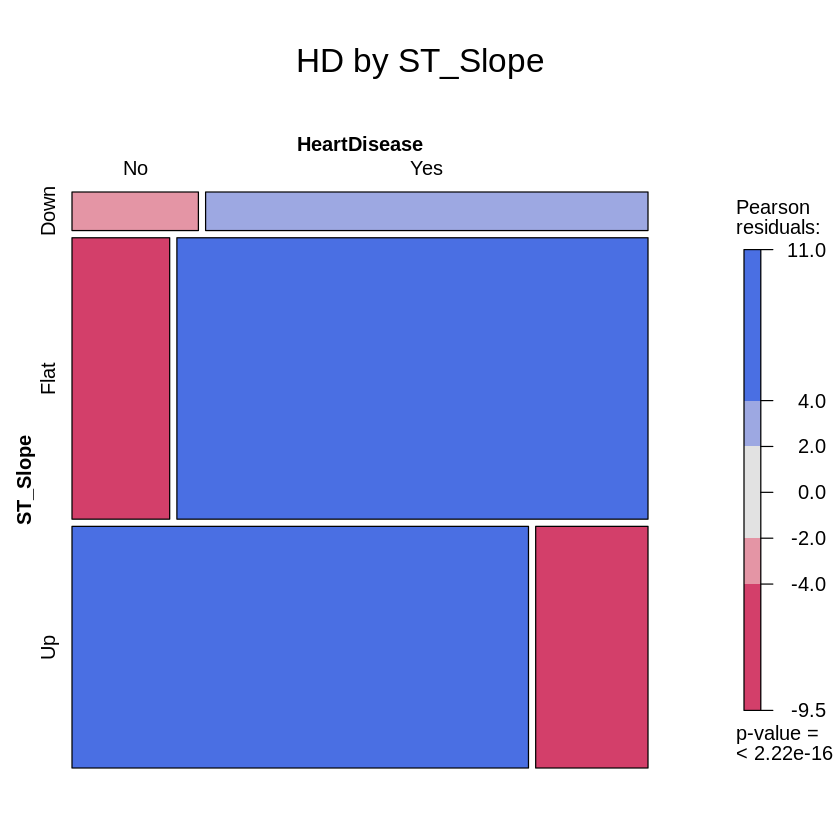

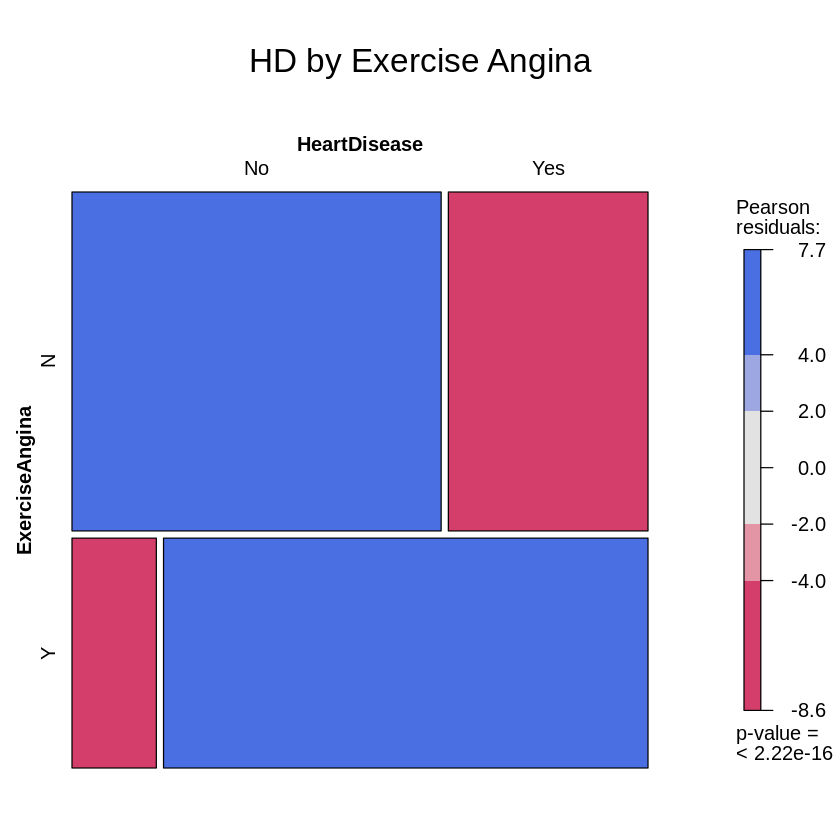

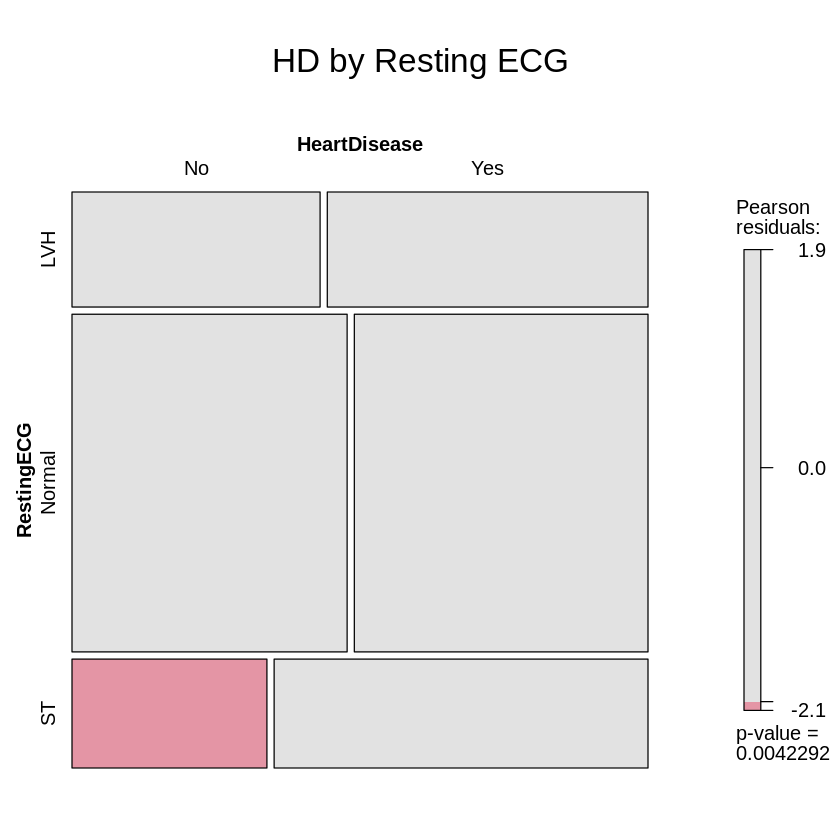

In [6]:
par(mfrow = c(1, 3))

mosaic(~ ST_Slope + HeartDisease, data = heart_data,
       main = "HD by ST_Slope", shade = TRUE, legend = TRUE)

mosaic(~ ExerciseAngina + HeartDisease, data = heart_data,
       main = "HD by Exercise Angina", shade = TRUE, legend = TRUE)

mosaic(~ RestingECG + HeartDisease, data = heart_data,
       main = "HD by Resting ECG", shade = TRUE, legend = TRUE)

1. Which variables appear useful for predicting HeartDisease?
   - The ST_Slope appears to be useful in predicting HeartDisease. With St_Slope those with an Up slope are more likely to not get HeartDisease and those who have a Flat or Down slope are likely to get a HeartDisease.

   - With ExerciseAngina also appearing to be useful in predicting HeartDisease. With ExerciseAngina those who do experience chest pain during exercise are more likely to get a HeartDisease compared to those who don't.

2. Which variables appear less useful?
   - The RestingECG showcases that the proportions of heart disease accross all three types of abnormality are all relatively similar. Making it not useful in predicting HeartDisease.

### 2. Relationships Among Predictors

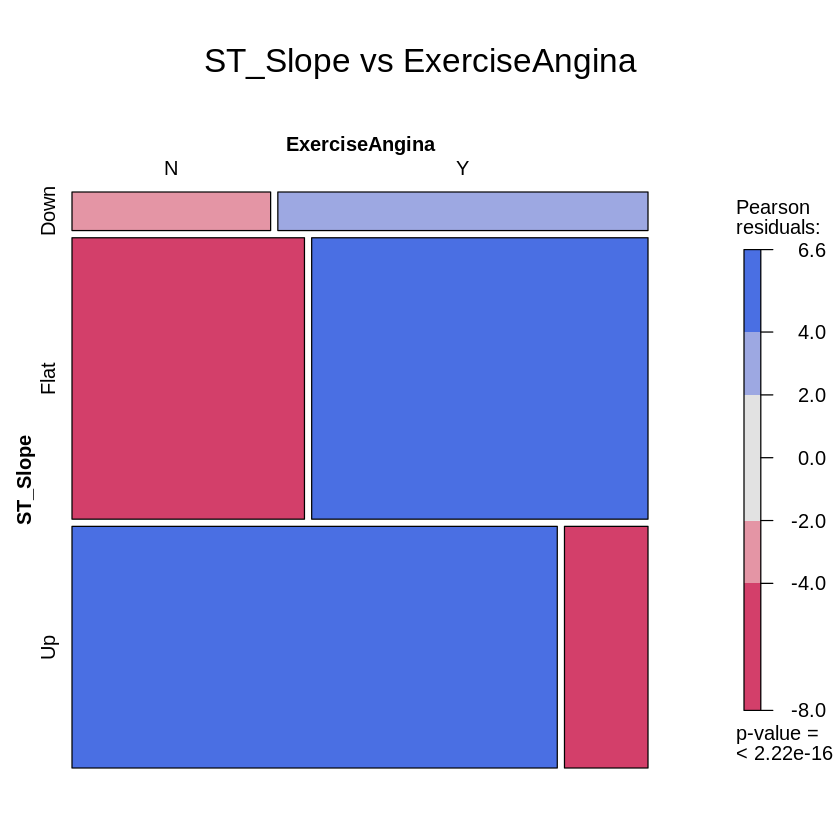

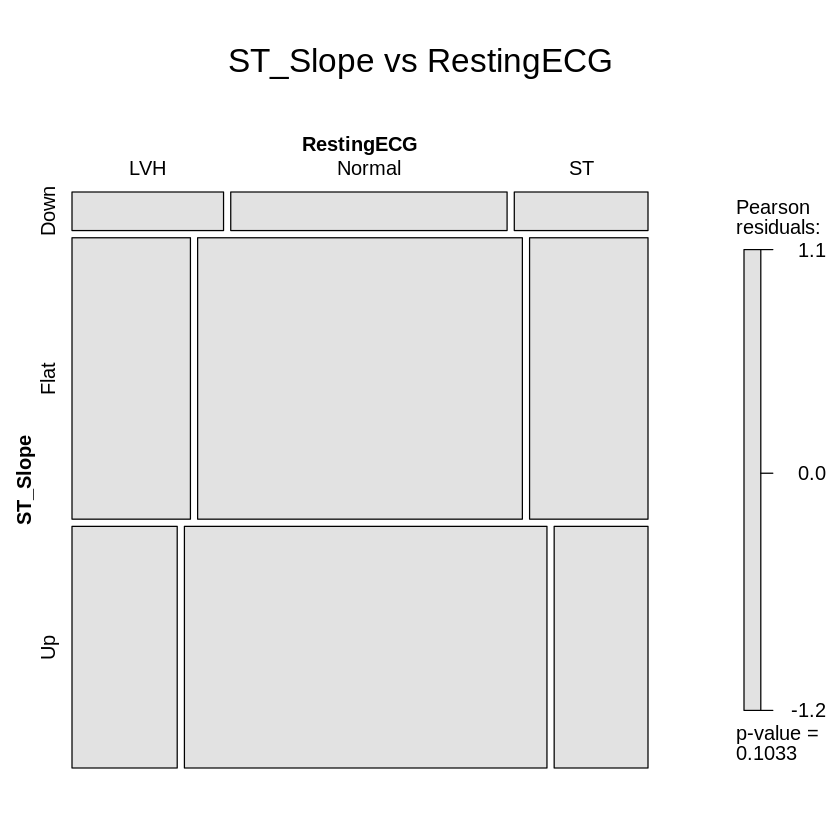

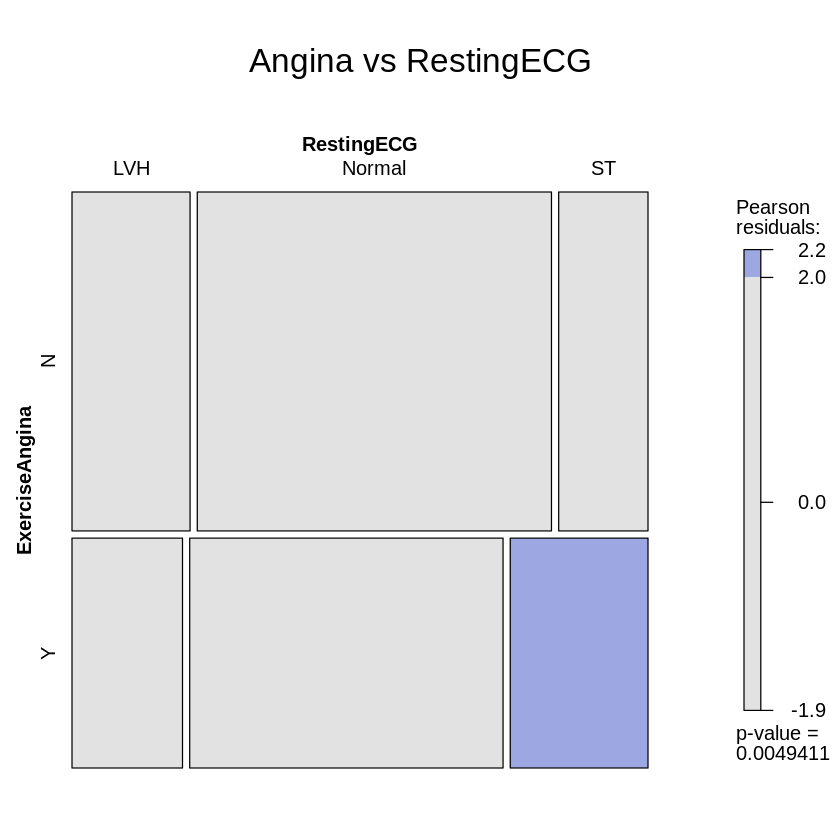

In [7]:
par(mfrow = c(1, 3))

mosaic(~ ST_Slope + ExerciseAngina, data = heart_data,
       main = "ST_Slope vs ExerciseAngina", shade = TRUE)

mosaic(~ ST_Slope + RestingECG, data = heart_data,
       main = "ST_Slope vs RestingECG", shade = TRUE)

mosaic(~ ExerciseAngina + RestingECG, data = heart_data,
       main = "Angina vs RestingECG", shade = TRUE)

Discussion:

Both St_Slope and ExerciseAngina are likely to be redundant as both of these variables are an indicator of a person's heart health. As a person who does feel chest pain when exercising is often likely to also have a Flat or Down Slope which both mean the same thing that the person's heart is not in good shape.

### 3. Cotabplot Investigation

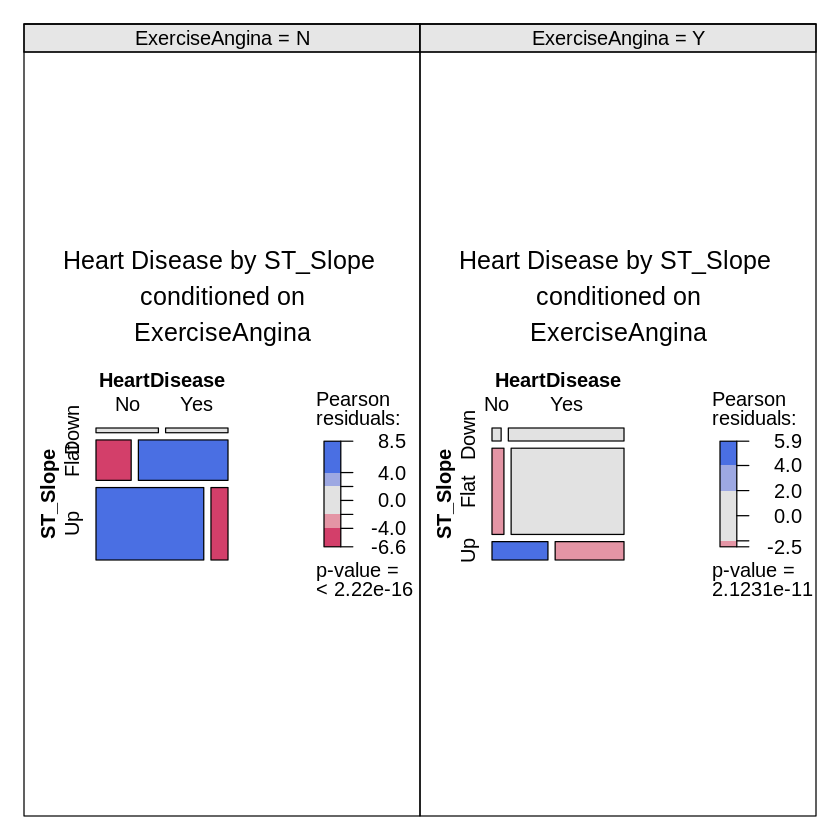

In [8]:
cotabplot(~ ST_Slope + HeartDisease | ExerciseAngina, data = heart_data,
          panel = cotab_mosaic, shade = TRUE,
          main = "Heart Disease by ST_Slope \n conditioned on \nExerciseAngina",
          main_gp = gpar(fontsize = 15))

Intepretation:

According to the cotabplot the combination of St_Slope and ExerciseAngina does in fact provide more predictive than individually.

It can be seen that when a person does not feel chest pain during exercise and has an Up slope they are almost guranteed to not have heart disease.

And the opposite is true with a person who does feel chest pain during exercise and has a Flat or Down Slope is almost guranteed to have heart disease.
